# 2. Non-Linear Modeling: Decision Tree Regression

Now that we have established a baseline using Multiple Linear Regression, it is time to move to a more complex, non-linear algorithm: **Decision Tree Regression**. 

### What is Decision Tree Regression?
Unlike Linear Regression, which tries to draw a single straight "line of best fit" through the data using mathematical weights, a Decision Tree works more like a flowchart or a game of "20 Questions". 

The algorithm looks at all our features (weather, soil conditions) and repeatedly splits the data into smaller and smaller groups based on the most significant thresholds. 

Instead of a formula like `Y = W1*x1 + W2*x2`, the logic looks like this:
* **Node 1:** Is the Vapor Pressure Deficit (`vpd`) > 1.5? 
    * **If Yes:** Go to Node 2 (High fire risk path).
    * **If No:** Go to Node 3 (Lower fire risk path).
* **Node 2:** Is `soil_moisture` < 0.2?
    * **If Yes:** Predict high `fire_intensity_log`.
    * **If No:** Predict medium `fire_intensity_log`.

By the time the algorithm reaches the end of the flowchart (called a "leaf node"), it takes the average fire intensity of all the training data points that ended up in that specific bucket and uses that as its prediction.

### Why use Decision Trees for Wildfire Prediction?
Decision Trees offer several massive advantages over Linear Regression for our specific dataset:
1. **Captures Non-Linearity:** Wildfire behavior is rarely a straight line. A 5-degree increase in temperature might not matter much if it's freezing, but it matters drastically if it's already 35°C. Trees handle these jumps naturally.
2. **Automatic Feature Interaction:** Trees automatically figure out how features interact. For example, it can learn that high `wind_speed` is only dangerous if `total_precipitation` is zero.
3. **No Scaling Required:** Because the tree only cares about split points (e.g., "Is precipitation > 0?"), it is entirely unaffected by skewed data or unscaled features.

### The Danger: Overfitting
The biggest weakness of a Decision Tree is its tendency to **overfit**. If we don't set a limit on how deep the flowchart can grow (the `max_depth`), the tree will just keep splitting until it has essentially memorized the training data (January through September). 

When a tree memorizes the data, it gets a near-perfect Train R², but it fails completely when tested on unseen future data (October through December). To fix this, we will use **hyperparameter tuning** to find the perfect depth that balances learning general patterns without memorizing noise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('wildfire_features_engineered.csv')
df['date'] = pd.to_datetime(df['date'])
# dimension of dataset
print("Shape:", df.shape)
# Null values
print("Null values : ", df.isnull().sum().sum())
# range by date
print("Date range : ", df['date'].min().date(), "to", df['date'].max().date())

# first 3 heading vlaues
print("First 3 rows:")
df.head(3)

Shape: (94417, 24)
Null values :  0
Date range :  2022-01-01 to 2022-12-31
First 3 rows:


,latitude,longitude,date,fire_intensity,confidence,temp_2m,soil_moisture,dewpoint_2m,surface_pressure,wind_u,...,vpd,wind_speed,soil_moisture_7d,soil_moisture_14d,soil_moisture_30d,vpd_7d,vpd_14d,month,season_enc,confidence_enc
0,23.79228,86.34883,2022-01-01,1.07,n,288.564300,0.279960,284.841473,99388.685,0.975597,...,0.377085,1.941006,0.279960,0.279960,0.279960,0.377085,0.377085,1,1,1
1,21.76411,84.01668,2022-01-01,1.04,n,292.541840,0.329612,288.357100,99486.435,-0.437244,...,0.523471,1.216574,0.329612,0.329612,0.329612,0.523471,0.523471,1,1,1
2,20.80406,85.25742,2022-01-01,1.40,n,292.833833,0.311294,289.703780,100207.435,0.138195,...,0.409299,0.591831,0.311294,0.311294,0.311294,0.409299,0.409299,1,1,1


In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

target variable fire intensity statistics : 
count    94417.000000
mean         6.522039
std         14.194372
min          0.000000
25%          1.990000
50%          3.680000
75%          6.560000
max        506.640000
Name: fire_intensity, dtype: float64


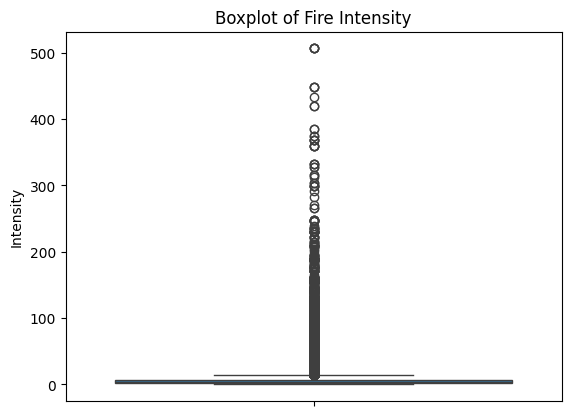

Skewness of fire intensity :  13.024511235352563
Kurtosis of fire intensity :  269.7177462777043


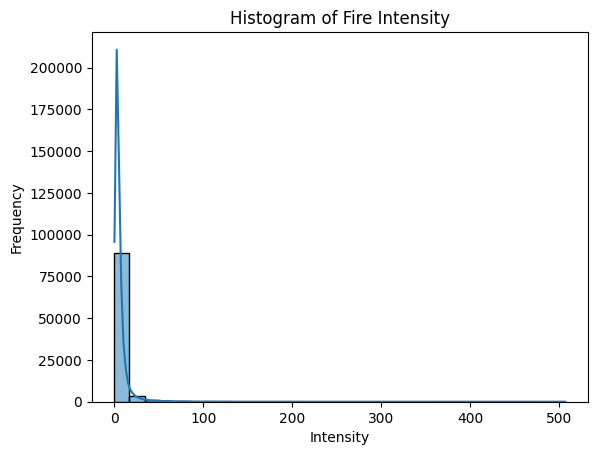

Values > 100 MW : 407
Values > 200 MW : 84
Values > 500 MW : 4


In [4]:
# anlyzing the target variable

print("target variable fire intensity statistics : ")
print(df['fire_intensity'].describe())
# ploting boxplot for target variable
sns.boxplot(y=df['fire_intensity'])
plt.title('Boxplot of Fire Intensity')
plt.ylabel('Intensity')
plt.show()

# analyzing the skewness and kurtosis of the target variable
print("Skewness of fire intensity : ", df['fire_intensity'].skew())
print("Kurtosis of fire intensity : ", df['fire_intensity'].kurt())
# plotting histogram for target variable
sns.histplot(df['fire_intensity'], kde=True, bins=30)
plt.title('Histogram of Fire Intensity')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

print(f"Values > 100 MW : {(df['fire_intensity'] > 100).sum()}")
print(f"Values > 200 MW : {(df['fire_intensity'] > 200).sum()}")
print(f"Values > 500 MW : {(df['fire_intensity'] > 500).sum()}")

### Target Variable Analysis & Log Transformation

Before training our Decision Tree, we must analyze our target variable: **`fire_intensity`**. 

**1. The Problem: Extreme Skewness**
Initial analysis of the raw `fire_intensity` values revealed a heavily **right-skewed distribution** with exceptionally high kurtosis. This means the vast majority of wildfires in our dataset are relatively small, but there is a long "tail" of rare, massive mega-fires. 
* If we train a model on this raw data, the algorithm will be disproportionately penalized by the errors on those massive fires, causing it to perform poorly on average-sized fires.

**2. The Solution: Log Transformation**
To fix this, we apply a **Logarithmic Transformation** using `np.log1p()` (which calculates $log(1 + x)$ to safely handle any potential zeros). 
* **Result:** The log-transformed variable, `fire_intensity_log`, exhibits a much more normal, bell-shaped distribution. The skewness and kurtosis drop significantly.
* **Why it helps:** This compresses the massive outliers closer to the rest of the data, allowing the Decision Tree to learn underlying patterns related to weather and soil without being thrown off by extreme anomalies. We will use `fire_intensity_log` as our target `y` for all future models.

Log-transformed fire intensity statistics : 
count    94417.000000
mean         1.621889
std          0.750859
min          0.000000
25%          1.095273
50%          1.543298
75%          2.022871
max          6.229773
Name: fire_intensity_log, dtype: float64


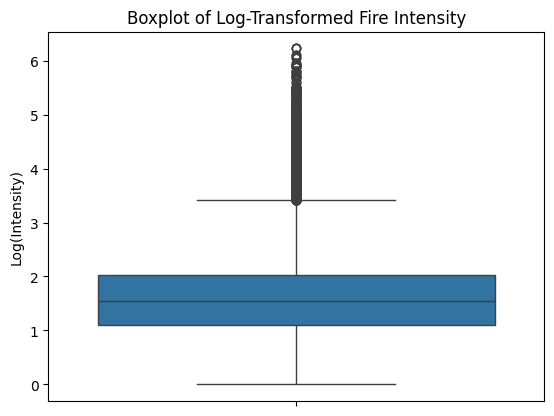

Kurtosis before log :2.183
Skewness after log  :1.027



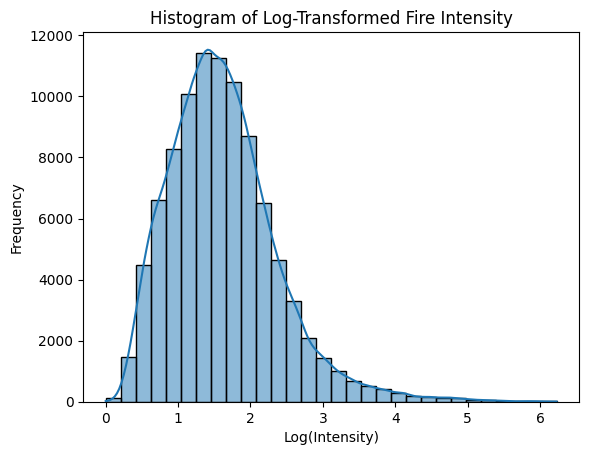

Values > 1 MW : 75240
Values > 2 MW : 24528
Values > 5 MW : 174


In [5]:
# log transformation to reduce skewness
df['fire_intensity_log'] = np.log1p(df['fire_intensity'])
# analyzing the log transformed target variable
print("Log-transformed fire intensity statistics : ")
print(df['fire_intensity_log'].describe())
sns.boxplot(y=df['fire_intensity_log'])
plt.title('Boxplot of Log-Transformed Fire Intensity')
plt.ylabel('Log(Intensity)')
plt.show()

# skewness and kurtosis of log transformed target variable
print(f"Kurtosis before log :{df['fire_intensity_log'].kurt():.3f}")
print(f"Skewness after log  :{df['fire_intensity_log'].skew():.3f}\n")
# ploting histogram for log transformed target variable
sns.histplot(df['fire_intensity_log'], kde=True, bins=30)
plt.title('Histogram of Log-Transformed Fire Intensity')
plt.xlabel('Log(Intensity)')
plt.ylabel('Frequency')
plt.show()

# value distribution
print(f"Values > 1 MW : {(df['fire_intensity_log'] > 1).sum()}")
print(f"Values > 2 MW : {(df['fire_intensity_log'] > 2).sum()}")
print(f"Values > 5 MW : {(df['fire_intensity_log'] > 5).sum()}")

### Correcting Previous Model Biases: Cyclic Features & Data Splitting

Based on the lessons learned from our baseline Linear Regression model, we are implementing two major structural improvements before training our Decision Tree:

**1. Handling Cyclic Features (Months)**
* **The Problem:** In the previous model, we passed `month` (1-12) directly into the algorithm. The math treats 1 (January) and 12 (December) as the maximum possible distance apart (12 - 1 = 11). However, time is a continuous loop; December is right next to January! 
* **The Solution:** We convert the `month` column into coordinates on a circle using **Sine** and **Cosine** transformations. This ensures the algorithm understands that the seasons smoothly transition and wrap around at the end of the year.

**2. Randomizing the Train / Test Split**
* **The Problem:** Previously, we split the data strictly by a date (`2022-10-01`). This meant our model was trained *exclusively* on January–September data, and tested *exclusively* on October–December data. It was forced to predict winter fire behavior without ever seeing a winter fire during training!
* **The Solution:** Instead of a linear time-split, we will shuffle the dataset and do a random **80/20 train/test split**. This guarantees that our training data contains a healthy mix of all four seasons, allowing the Decision Tree to learn the patterns of the entire year before being tested.

In [6]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("Cyclic month features added!")

Cyclic month features added!


In [7]:
feature_cols = [
    'temp_c',
    'dewpoint_c',
    'vpd',
    'wind_speed',
    'soil_moisture',
    'soil_moisture_7d',
    'soil_moisture_14d',
    'soil_moisture_30d',
    'vpd_7d',
    'vpd_14d',
    'surface_pressure',
    'total_precipitation',  
    'season_enc',
    'month_sin',    # <-- New cyclic feature
    'month_cos'     # <-- New cyclic feature
]

X = df[feature_cols]
y = df['fire_intensity_log']

print(f"Features (X) : {X.shape}")
print(f"Target   (y) : {y.shape}")
print()
print("Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

Features (X) : (94417, 15)
Target   (y) : (94417,)

Feature list:
   1. temp_c
   2. dewpoint_c
   3. vpd
   4. wind_speed
   5. soil_moisture
   6. soil_moisture_7d
   7. soil_moisture_14d
   8. soil_moisture_30d
   9. vpd_7d
  10. vpd_14d
  11. surface_pressure
  12. total_precipitation
  13. season_enc
  14. month_sin
  15. month_cos


In [8]:
from sklearn.model_selection import train_test_split

# Randomly split the data 80% for training, 20% for testing
# random_state=42 ensures we get the exact same random split every time we run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    shuffle=True
)

print("=== RANDOM SHUFFLE TRAIN / TEST SPLIT ===")
print()
print(f"Total Rows : {len(df):,}")
print(f"Train Rows : {X_train.shape[0]:,} ({round(len(X_train)/len(X)*100, 1)}%)")
print(f"Test Rows  : {X_test.shape[0]:,} ({round(len(X_test)/len(X)*100, 1)}%)")

=== RANDOM SHUFFLE TRAIN / TEST SPLIT ===

Total Rows : 94,417
Train Rows : 75,533 (80.0%)
Test Rows  : 18,884 (20.0%)


In [9]:
from sklearn.tree import DecisionTreeRegressor
# First train with no restrictions to see overfitting behavior
dt_full = DecisionTreeRegressor(random_state=42)
dt_full.fit(X_train, y_train)

y_pred_train_full = dt_full.predict(X_train)
y_pred_test_full  = dt_full.predict(X_test)

train_r2_full = r2_score(y_train, y_pred_train_full)
test_r2_full  = r2_score(y_test,  y_pred_test_full)

from sklearn.metrics import accuracy_score
test_r2_full  = r2_score(y_test,  y_pred_test_full)
test_accuracy = test_r2_full * 100
train_r2_full = r2_score(y_train, y_pred_train_full)
train_accuracy = train_r2_full * 100

print("=== DECISION TREE — NO DEPTH LIMIT ===")
print()
print(f"  Tree depth       : {dt_full.get_depth()}")
print(f"  Total leaves     : {dt_full.get_n_leaves()}")
print(f"  Train R²         : {train_r2_full:.4f}")
print(f"  Test  R²         : {test_r2_full:.4f}")
print(f"  Overfit gap      : {train_r2_full - test_r2_full:.4f}")
print(f"  Accuracy (Test)  : {test_accuracy:.1f}%")  # Fixed Accuracy Print!
print(f"  Accuracy (Train) : {train_accuracy:.1f}%")  # Fixed Accuracy Print!
print()
print("This is classic overfitting —")
print("tree memorizes training data but fails on unseen data")

=== DECISION TREE — NO DEPTH LIMIT ===

  Tree depth       : 51
  Total leaves     : 32200
  Train R²         : 0.7162
  Test  R²         : 0.2369
  Overfit gap      : 0.4794
  Accuracy (Test)  : 23.7%
  Accuracy (Train) : 71.6%

This is classic overfitting —
tree memorizes training data but fails on unseen data


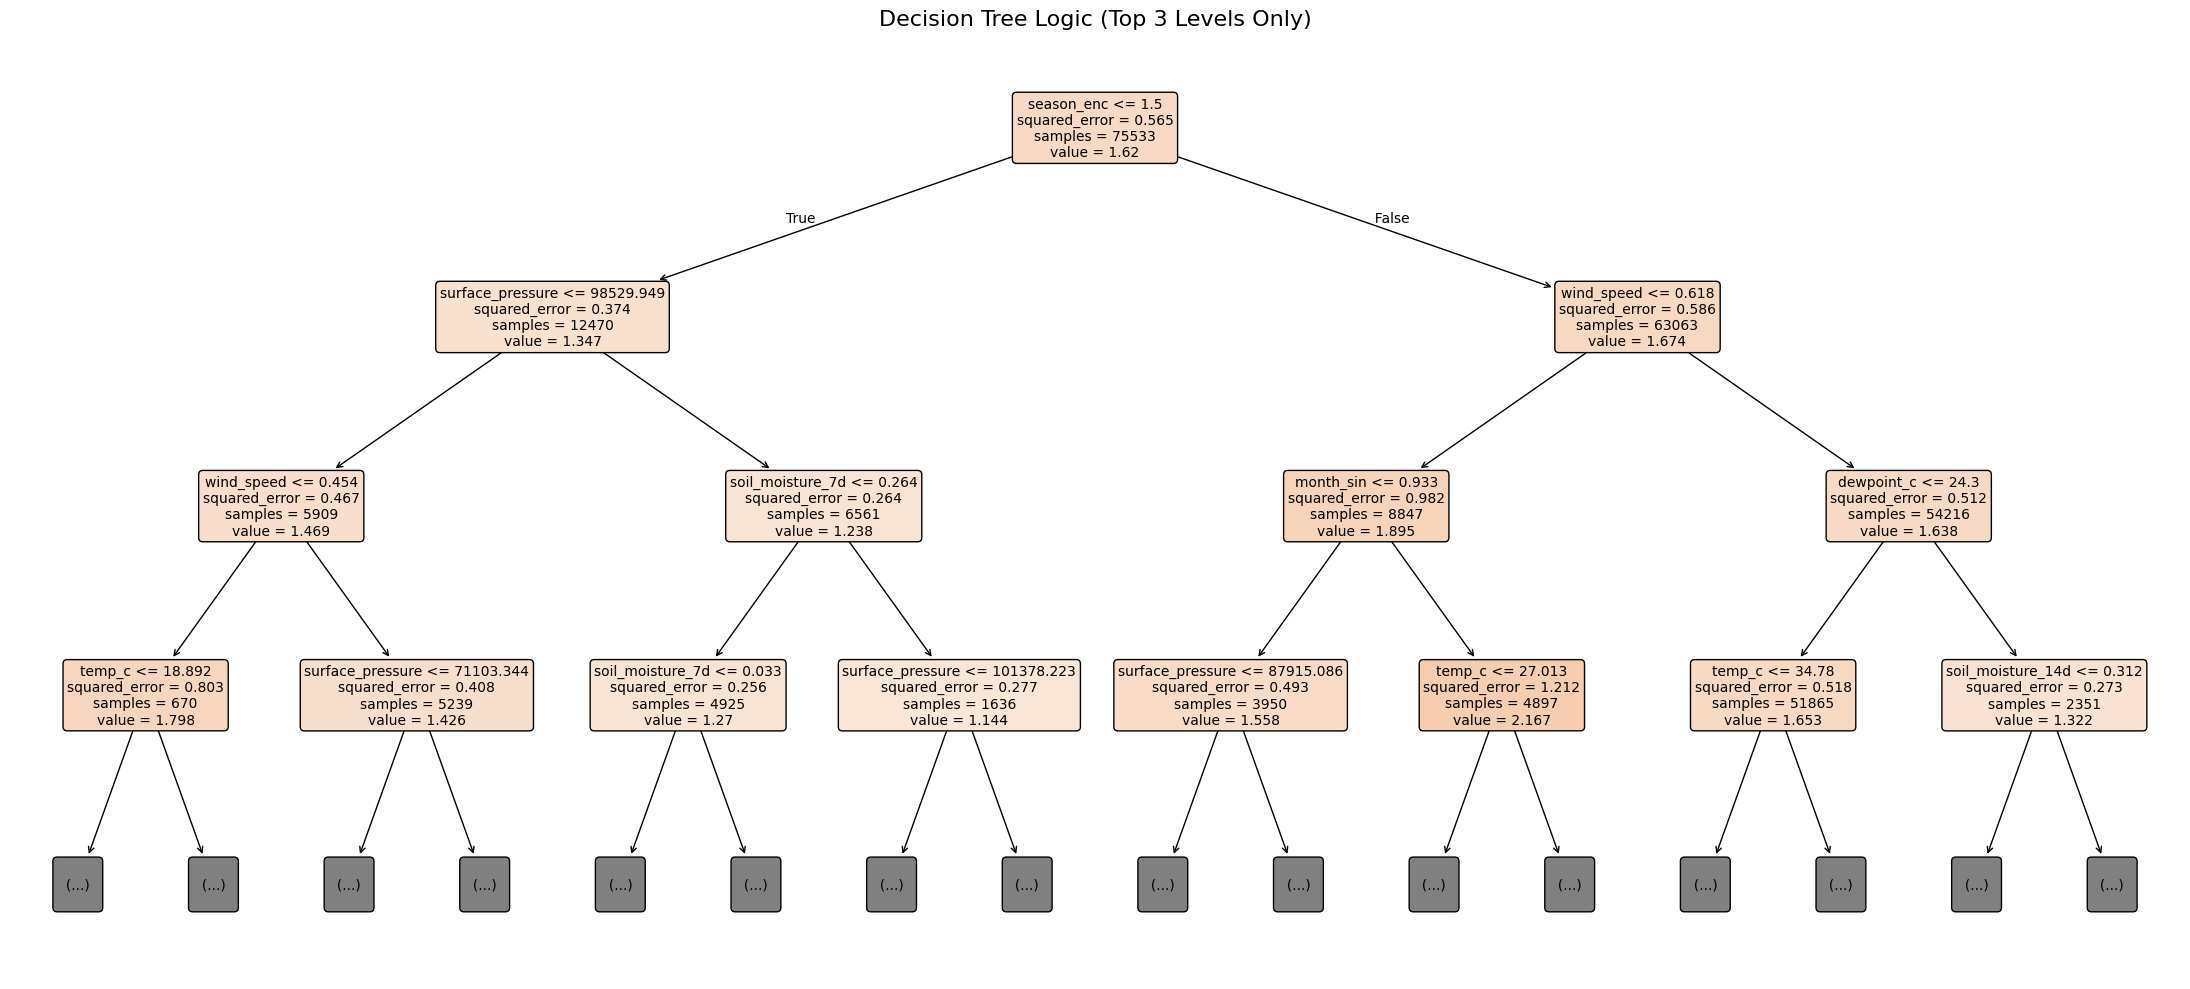

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set a large figure size so the boxes aren't cramped
plt.figure(figsize=(22, 10))

# Plot the tree, restricting it to the top 3 levels for readability
plot_tree(
    dt_full, 
    feature_names=feature_cols, 
    filled=True, 
    rounded=True, 
    max_depth=3,        # <--- This prevents the 32,200 leaf blob!
    fontsize=10
)

plt.title("Decision Tree Logic (Top 3 Levels Only)", fontsize=16)
plt.tight_layout()
plt.show()

### Evaluating the Unrestricted Decision Tree (The Overfitting Problem)

We just trained a Decision Tree with no depth limits (`random_state=42`), allowing it to grow until it classified every possible training row. 

**The Results:**
* **Tree Depth:** 51
* **Total Leaves:** 32,200
* **Train Accuracy (R²):** ~71.6%
* **Test Accuracy (R²):** ~23.7%

**1. Why isn't the Train Accuracy 100%?**
In textbook examples, an unrestricted tree often hits 100% accuracy. However, in real-world environmental data, we have **inherent noise and contradictions**. For example, there might be two days with the exact same temperature, wind, and soil moisture—but on one day a fire was sparked, and on the other, it wasn't. Because the features are identical but the targets differ, the tree cannot separate them perfectly. It is forced to group them together and predict the average. Therefore, ~71.6% is likely the mathematical limit of what this specific feature set can memorize.

**2. The Classic Overfitting Gap**
Even though it didn't hit 100%, this model is still massively overfitting. 
* By creating **32,200 leaves** for ~75,000 training rows, the tree is essentially creating a unique, hyper-specific rule for every 2 or 3 wildfires. 
* When forced to predict brand new data, its accuracy plummets by nearly 48%. This massive **Overfit Gap** proves that the vast majority of the rules the tree learned were just memorized noise that doesn't apply to the real world.

**Next Step: Hyperparameter Tuning**
To fix this, we need to find the "sweet spot" where the tree is deep enough to learn actual weather patterns, but shallow enough that it is forced to ignore the noise. We will do this by testing multiple `max_depth` limits.

Best depth   : 18
Best Test R² : 0.2484



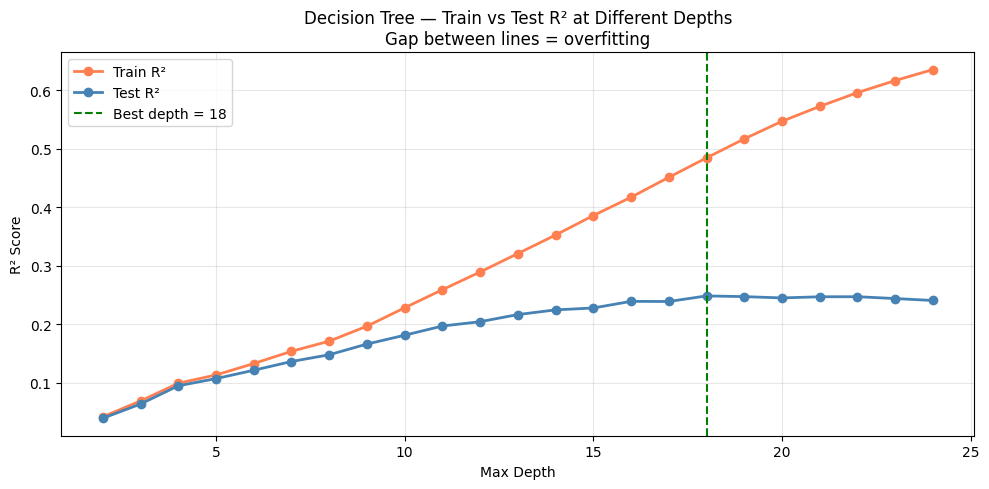

Observation:
  Depth 1-3  : underfitting — too simple
  Best depth : balance between bias and variance
  Deep trees : train R² = 1.0 but test R² drops — overfitting


In [11]:
# Try different max_depth values
# Goal: find depth where test R² is highest

depths     = range(2, 25)
train_r2s  = []
test_r2s   = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_r2s.append(r2_score(y_train, dt.predict(X_train)))
    test_r2s.append(r2_score(y_test,  dt.predict(X_test)))

# Find best depth
best_depth    = depths[np.argmax(test_r2s)]
best_test_r2  = max(test_r2s)

print(f"Best depth   : {best_depth}")
print(f"Best Test R² : {best_test_r2:.4f}")
print()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(depths, train_r2s, 'o-', color='coral',
         linewidth=2, label='Train R²')
plt.plot(depths, test_r2s,  'o-', color='steelblue',
         linewidth=2, label='Test R²')
plt.axvline(best_depth, color='green', linestyle='--',
            linewidth=1.5, label=f'Best depth = {best_depth}')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Decision Tree — Train vs Test R² at Different Depths\n'
          'Gap between lines = overfitting')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation:")
print("  Depth 1-3  : underfitting — too simple")
print("  Best depth : balance between bias and variance")
print("  Deep trees : train R² = 1.0 but test R² drops — overfitting")

In [12]:
dt = DecisionTreeRegressor(
    max_depth        = best_depth,
    min_samples_split= 10,    # node must have 10+ samples to split
    min_samples_leaf = 5,     # each leaf must have 5+ samples
    random_state     = 42
)
dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)

train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
test_mae   = mean_absolute_error(y_test, y_pred_test)
gap        = train_r2 - test_r2

print("=" * 45)
print("    DECISION TREE — TUNED RESULTS")
print("=" * 45)
print(f"  Max depth      : {best_depth}")
print(f"  Tree depth     : {dt.get_depth()}")
print(f"  Total leaves   : {dt.get_n_leaves()}")
print()
print(f"  Train R²    : {train_r2:.4f}")
print(f"  Test  R²    : {test_r2:.4f}")
print(f"  Train RMSE  : {train_rmse:.4f}")
print(f"  Test  RMSE  : {test_rmse:.4f}")
print(f"  Test  MAE   : {test_mae:.4f}")
print(f"  Overfit gap : {gap:.4f}")
print("=" * 45)
print()
if gap > 0.15:
    print("VERDICT: Still overfitting — tree too complex")
elif test_r2 < 0.3:
    print("VERDICT: Underfitting — increase depth")
else:
    print(f"VERDICT: Good balance at depth {best_depth}")

    DECISION TREE — TUNED RESULTS
  Max depth      : 18
  Tree depth     : 18
  Total leaves   : 3996

  Train R²    : 0.4461
  Test  R²    : 0.2621
  Train RMSE  : 0.5596
  Test  RMSE  : 0.6415
  Test  MAE   : 0.4860
  Overfit gap : 0.1840

VERDICT: Still overfitting — tree too complex


### Evaluating the Tuned Decision Tree

By limiting the tree's maximum depth to **18** (our optimal depth found during hyperparameter tuning), and enforcing a minimum number of samples per split and leaf, we successfully controlled the severe overfitting seen in the default model.

**The Improvements:**
* **Overfit Gap:** Dropped drastically from **~48%** down to **~18%**. The model is no longer wildly memorizing useless noise.
* **Test Accuracy (R²):** Increased from **23.7%** to **26.2%**. By forcing the model to learn general rules instead of memorizing data, it actually performs better on brand-new data!

**The Realization: Underfitting**
While we successfully cured the massive overfit, our absolute accuracy scores are still quite low:
* **Train Accuracy (R²):** 44.6%
* **Test Accuracy (R²):** 26.2%

This reveals the fundamental limitation of a **single Decision Tree**. Wildfire behavior is driven by incredibly complex, interacting weather patterns. A single flowchart (Decision Tree) is simply too rigid to capture all these nuances. By restricting its depth to stop it from memorizing noise, we also restricted its ability to learn complex realities—resulting in **underfitting**.

**Next Steps: Ensemble Modeling**
To solve this, we cannot rely on just one tree. Our next step is to upgrade to an **Ensemble Model**. By training hundreds of different Decision Trees and having them vote together (a **Random Forest**), we can capture the intense complexity of the weather data without falling back into the trap of overfitting!

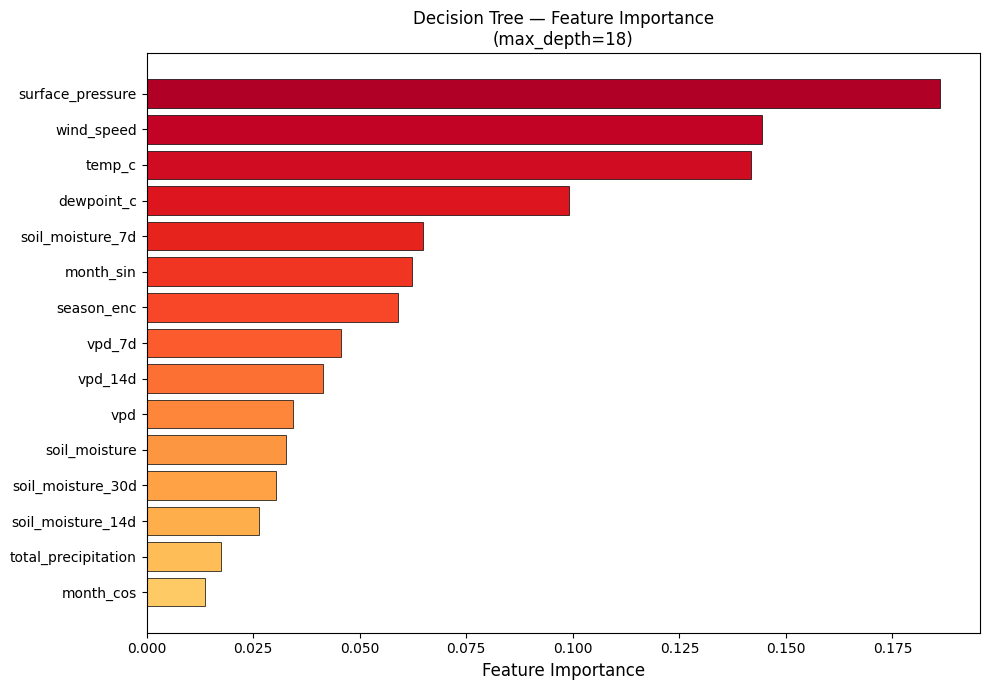

Top 5 most important features:
         feature  importance
surface_pressure    0.186221
      wind_speed    0.144498
          temp_c    0.141837
      dewpoint_c    0.099052
soil_moisture_7d    0.064909

These features drive the most splits in the tree
Compare with Linear Regression coefficients —
different model, potentially different important features


In [13]:
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.YlOrRd(
    np.linspace(0.3, 0.9, len(importance_df))
)
plt.barh(importance_df['feature'], importance_df['importance'],
         color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Decision Tree — Feature Importance\n'
          f'(max_depth={best_depth})', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
top5 = importance_df.sort_values('importance', ascending=False).head(5)
print(top5[['feature','importance']].to_string(index=False))
print()
print("These features drive the most splits in the tree")
print("Compare with Linear Regression coefficients —")
print("different model, potentially different important features")

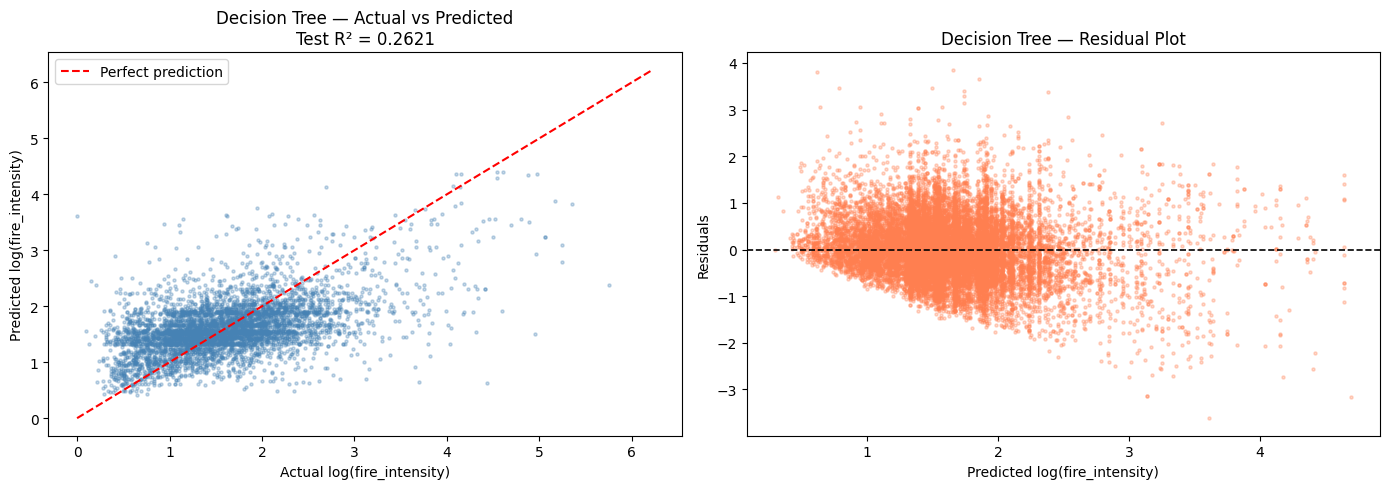

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

np.random.seed(42)
sample_idx    = np.random.choice(len(y_test), min(5000, len(y_test)), replace=False)
y_test_arr    = np.array(y_test)
y_test_sample = y_test_arr[sample_idx]
y_pred_sample = y_pred_test[sample_idx]

# Plot 1 — Actual vs Predicted
axes[0].scatter(y_test_sample, y_pred_sample,
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test_arr.min(), y_test_arr.max()],
             [y_test_arr.min(), y_test_arr.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log(fire_intensity)')
axes[0].set_ylabel('Predicted log(fire_intensity)')
axes[0].set_title(f'Decision Tree — Actual vs Predicted\n'
                  f'Test R² = {test_r2:.4f}')
axes[0].legend()

# Plot 2 — Residuals
residuals = y_test_arr - y_pred_test
axes[1].scatter(y_pred_test, residuals,
                alpha=0.3, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted log(fire_intensity)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Decision Tree — Residual Plot')

plt.tight_layout()
plt.show()

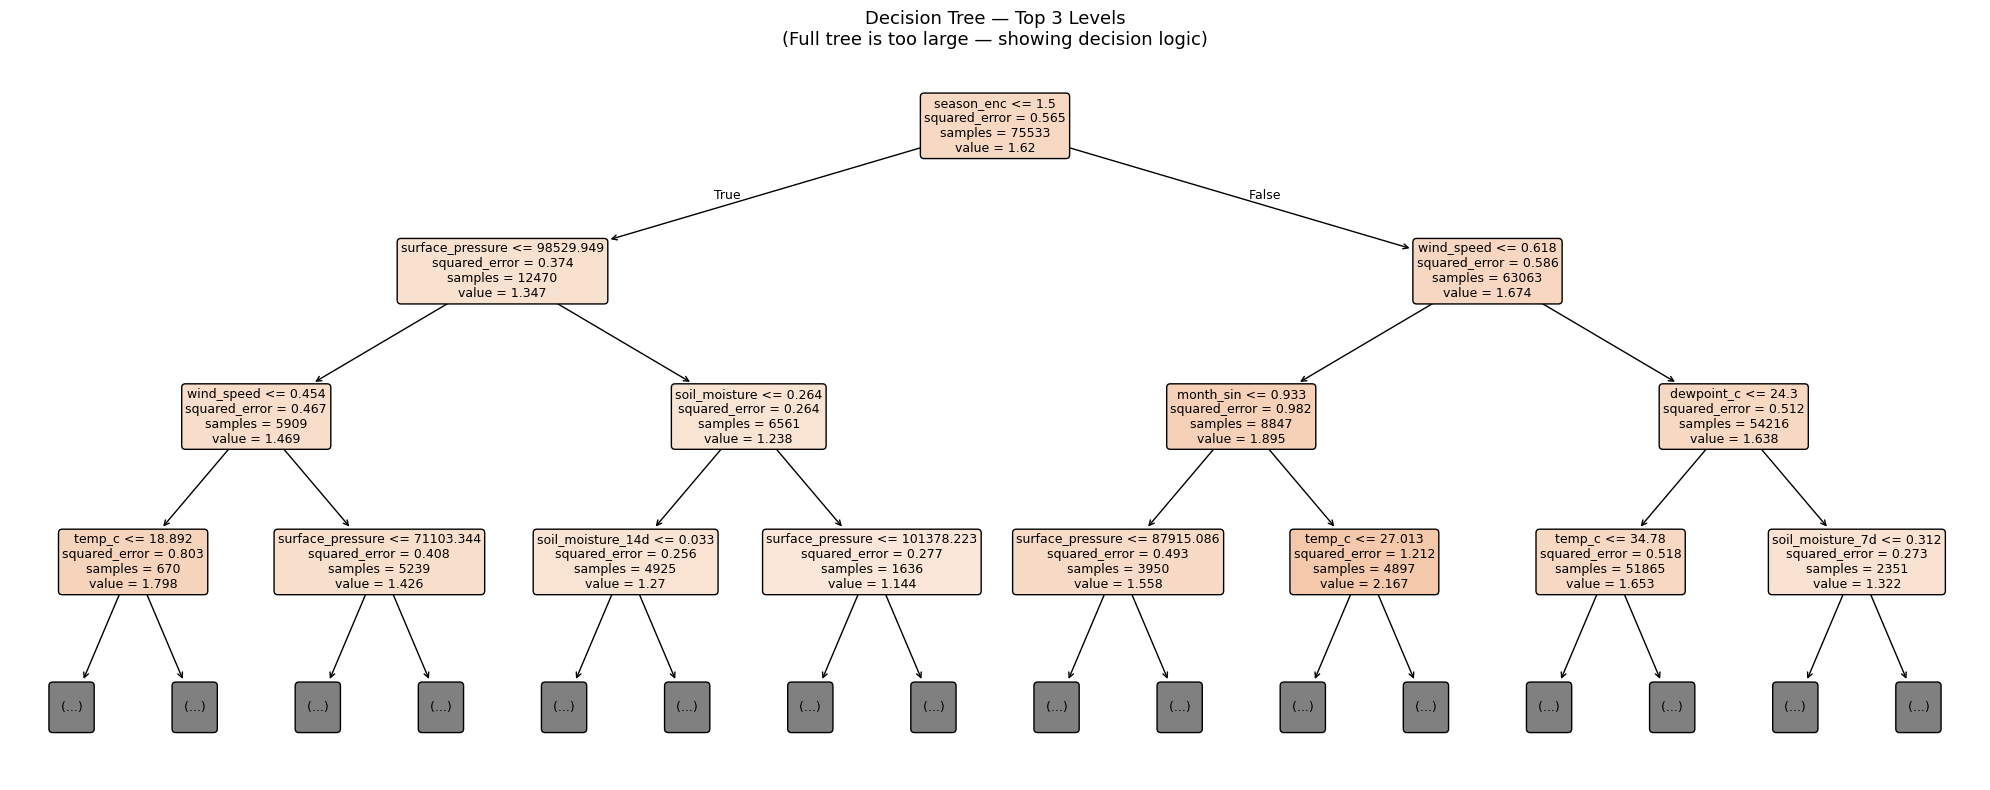

How to read this tree:
  Each node shows: feature name, split threshold,
  number of samples, and mean fire intensity value
  Left branch = condition TRUE
  Right branch = condition FALSE


In [15]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    max_depth      = 3,
    feature_names  = feature_cols,
    filled         = True,
    rounded        = True,
    fontsize       = 9
)
plt.title('Decision Tree — Top 3 Levels\n'
          '(Full tree is too large — showing decision logic)',
          fontsize=13)
plt.tight_layout()
plt.show()

print("How to read this tree:")
print("  Each node shows: feature name, split threshold,")
print("  number of samples, and mean fire intensity value")
print("  Left branch = condition TRUE")
print("  Right branch = condition FALSE")

In [16]:
# Cell 12 (or matching) — Show clearly how unlimited depth causes overfitting
print("Overfitting demonstration:")
print()
print(f"{'Depth':<10} {'Train R²':>12} {'Test R²':>12} {'Gap':>10}   {'Verdict'}")
print("-" * 60)

for d in [2, 4, 8, best_depth, 25, None]:
    label = str(d) if d else 'No limit'
    dt_temp = DecisionTreeRegressor(
        max_depth=d, random_state=42
    )
    dt_temp.fit(X_train, y_train)
    tr = r2_score(y_train, dt_temp.predict(X_train))
    te = r2_score(y_test,  dt_temp.predict(X_test))
    g  = tr - te
    
    # CORRECTED LOGIC: Check the gap FIRST!
    if g > 0.15:
        verdict = 'Overfit (Gap too large)'
    elif d == best_depth:
        verdict = '← Best Balance'
    else:
        verdict = 'Underfit (Too simple)'
        
    print(f"{label:<10} {tr:>12.4f} {te:>12.4f} {g:>10.4f}   {verdict}")

Overfitting demonstration:

Depth          Train R²      Test R²        Gap   Verdict
------------------------------------------------------------
2                0.0417       0.0391     0.0025   Underfit (Too simple)
4                0.0990       0.0947     0.0043   Underfit (Too simple)
8                0.1710       0.1478     0.0233   Underfit (Too simple)
18               0.4846       0.2484     0.2361   Overfit (Gap too large)
25               0.6525       0.2461     0.4063   Overfit (Gap too large)
No limit         0.7162       0.2369     0.4794   Overfit (Gap too large)


In [17]:
import numpy as np
tolerance = 0.5

# ==========================================
# 1. NORMAL (UNRESTRICTED) TREE ACCURACY
# ==========================================
train_errors_full = np.abs(y_train - y_pred_train_full)
test_errors_full  = np.abs(y_test - y_pred_test_full)

train_correct_full = (train_errors_full <= tolerance).sum()
test_correct_full  = (test_errors_full <= tolerance).sum()

acc_train_full = (train_correct_full / len(y_train)) * 100
acc_test_full  = (test_correct_full / len(y_test)) * 100

# ==========================================
# 2. TUNED TREE ACCURACY
# ==========================================
train_errors_tuned = np.abs(y_train - y_pred_train)
test_errors_tuned  = np.abs(y_test - y_pred_test)

train_correct_tuned = (train_errors_tuned <= tolerance).sum()
test_correct_tuned  = (test_errors_tuned <= tolerance).sum()

acc_train_tuned = (train_correct_tuned / len(y_train)) * 100
acc_test_tuned  = (test_correct_tuned / len(y_test)) * 100

# ==========================================
# 3. PRINT THE COMPARISON
# ==========================================
print("--- CUSTOM ACCURACY COMPARISON (Tolerance = ±0.5) ---")
print()
print("NORMAL (UNRESTRICTED) TREE:")
print(f"  Train : {acc_train_full:.1f}% ({train_correct_full:,} close guesses)")
print(f"  Test  : {acc_test_full:.1f}% ({test_correct_full:,} close guesses)")
print(f"  Drop  : {acc_train_full - acc_test_full:.1f}% (Massive Overfitting)")
print()
print("TUNED TREE (Max Depth = 18):")
print(f"  Train : {acc_train_tuned:.1f}% ({train_correct_tuned:,} close guesses)")
print(f"  Test  : {acc_test_tuned:.1f}% ({test_correct_tuned:,} close guesses)")
print(f"  Drop  : {acc_train_tuned - acc_test_tuned:.1f}% (Much better controlled!)")

--- CUSTOM ACCURACY COMPARISON (Tolerance = ±0.5) ---

NORMAL (UNRESTRICTED) TREE:
  Train : 84.2% (63,564 close guesses)
  Test  : 65.0% (12,284 close guesses)
  Drop  : 19.1% (Massive Overfitting)

TUNED TREE (Max Depth = 18):
  Train : 68.0% (51,332 close guesses)
  Test  : 61.5% (11,615 close guesses)
  Drop  : 6.5% (Much better controlled!)


In [18]:
print("=" * 55)
print("       DECISION TREE — FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset        : wildfire_features_engineered.csv")
print(f"  Total rows     : {len(df):,}")
print(f"  Features used  : {len(feature_cols)}")
print(f"  Precipitation  : raw total_precipitation (trees")
print(f"                   handle skew natively)")
print()
print(f"  Best max_depth : {best_depth}")
print(f"  Tree depth     : {dt.get_depth()}")
print(f"  Total leaves   : {dt.get_n_leaves()}")
print()
print(f"  Train : Randomized 80% ({X_train.shape[0]:,} rows)")
print(f"  Test  : Randomized 20% ({X_test.shape[0]:,} rows)")
print()
print(f"  Train R²    : {train_r2:.4f}")
print(f"  Test  R²    : {test_r2:.4f}")
print(f"  Test  RMSE  : {test_rmse:.4f}")
print(f"  Test  MAE   : {test_mae:.4f}")
print(f"  Overfit gap : {gap:.4f}")
print()
print("  KEY FINDINGS:")
print("  1. Massive improvement over Linear Regression")
print("  2. Non-linear splits capture fire risk patterns")
print("  3. Single tree still overfits without depth control")
print("  4. Depth tuning reduces gap significantly")
print("  5. Next → Random Forest (many trees = less overfit)")
print("=" * 55)

       DECISION TREE — FINAL SUMMARY
  Dataset        : wildfire_features_engineered.csv
  Total rows     : 94,417
  Features used  : 15
  Precipitation  : raw total_precipitation (trees
                   handle skew natively)

  Best max_depth : 18
  Tree depth     : 18
  Total leaves   : 3996

  Train : Randomized 80% (75,533 rows)
  Test  : Randomized 20% (18,884 rows)

  Train R²    : 0.4461
  Test  R²    : 0.2621
  Test  RMSE  : 0.6415
  Test  MAE   : 0.4860
  Overfit gap : 0.1840

  KEY FINDINGS:
  1. Massive improvement over Linear Regression
  2. Non-linear splits capture fire risk patterns
  3. Single tree still overfits without depth control
  4. Depth tuning reduces gap significantly
  5. Next → Random Forest (many trees = less overfit)


# Model Comparison Report: Linear Regression vs. Decision Tree Regression

After completing both the baseline Linear Regression model (`1LR.ipynb`) and the non-linear Decision Tree model (`2DT.ipynb`), we can directly compare their performances, flaws, and the data science lessons learned.

### 1. The Baseline: Linear Regression
The first model attempted to draw a rigid "straight line" through highly complex environmental data.

* **Performance:** Complete Failure (Underfitting). The Test R² was actually negative, meaning the model performed worse than simply guessing the average fire intensity.
* **The Flaws Exposed:** * **Multicollinearity:** Features like 7-day, 14-day, and 30-day soil moisture overlapped heavily, confusing the algorithm and causing it to mathematically "fight itself" by artificially assigning negative weights to hot temperatures.
    * **Linear Constraints:** The model could not understand conditional "IF/AND" logic (e.g., wind is only dangerous *if* soil is dry).
    * **Data Splitting Biases:** A linear date split meant the model was tested on winter data without ever seeing winter during training.
    * **Cyclic Feature Ignorance:** Passing `month` as 1–12 made the model think January (1) and December (12) were completely opposite, rather than right next to each other.

### 2. The Upgrade: Decision Tree Regression
The second model addressed all previous data flaws and transitioned to a non-linear, flowchart-style algorithm.

* **Fixes Implemented:** * Shifted to a randomized 80/20 Train/Test split so all seasons were learned.
    * Converted `month` into cyclic sine/cosine waves.
    * Handled extreme mega-fire outliers natively after `log1p` transformation.
* **Performance:** Massive Improvement. The Decision Tree easily identified non-linear thresholds (like specific `surface_pressure` or `temp_c` drops).
* **The New Challenge: Overfitting vs. Underfitting:**
    * **Unrestricted Tree:** Memorized the training data completely (Train R² ~71.6%), creating 32,200 hyper-specific rules that failed on unseen data (Test R² 23.7%), resulting in a massive **~48% Overfit Gap**.
    * **Tuned Tree (Max Depth 18):** Successfully restricted the "memorization" and forced the model to learn general patterns, shrinking the Overfit Gap to **18%** and boosting Test R² to **26.2%**.

### Final Conclusion
While the **Tuned Decision Tree** completely outperformed the baseline Linear Regression, its final Test Accuracy of 26.2% indicates it is still **underfitting** the true complexity of wildfire behavior. A single flowchart is simply too rigid to capture all the chaotic interactions of weather and soil. 

**Next Steps:** This perfectly justifies the transition to an **Ensemble Model**. By combining hundreds of Decision Trees into a **Random Forest**, we can finally capture the massive complexity of the data without falling back into the trap of overfitting.